# Assignment 2 — HOG Features (12 points)

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import color, data, exposure, filters, transform
from skimage.feature import hog
from skimage.util import img_as_float

## 1. HOG script

In [41]:
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 10, "font.size": 9})

def to_grayscale(img, max_side=512):
    # Convert an image array to grayscale floats in [0, 1]; shrink large images, keeping aspect ratio.
    if img.ndim == 3:
        if img.shape[2] == 4:
            img = color.rgba2rgb(img)
        img = color.rgb2gray(img)
    img = img_as_float(img)
    scale = max_side / max(img.shape)
    if scale < 1:
        img = transform.rescale(img, scale, anti_aliasing=True)
    return img

def compute_hog(image, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2),
                block_norm="L2-Hys", visualize=True):
    # Return (feature_vector, hog_image) - or only the feature vector if visualize=False.
    return hog(image, orientations=orientations, pixels_per_cell=pixels_per_cell,
               cells_per_block=cells_per_block, block_norm=block_norm,
               visualize=visualize, feature_vector=True)

def describe_hog(image, features, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
    # Explain how the image was divided and check the feature length against the formula.
    n_cells = (image.shape[0] // pixels_per_cell[0], image.shape[1] // pixels_per_cell[1])
    n_blocks = (n_cells[0] - cells_per_block[0] + 1, n_cells[1] - cells_per_block[1] + 1)
    per_block = cells_per_block[0] * cells_per_block[1] * orientations
    expected = n_blocks[0] * n_blocks[1] * per_block
    print(f"  image {image.shape[1]}×{image.shape[0]} px | cells {n_cells[1]}×{n_cells[0]} | "
          f"block positions {n_blocks[1]}×{n_blocks[0]} × {per_block} values | "
          f"feature length {features.size} (formula: {expected})")

## 2. Applying the script to four images

In [42]:
images = {
    "Horse (simple)":      filters.gaussian(to_grayscale(data.horse()), sigma=1),    # black silhouette on white
    "Brick (texture)":     to_grayscale(data.brick()),
    "Cameraman (medium)":  to_grayscale(data.camera()),
    "Astronaut (complex)": to_grayscale(data.astronaut()),
}

results = {}
for name, img in images.items():
    fd, hog_img = compute_hog(img)
    results[name] = {"img": img, "fd": fd, "hog": hog_img}
    print(name); describe_hog(img, fd)

Horse (simple)
  image 400×328 px | cells 50×41 | block positions 49×40 × 36 values | feature length 70560 (formula: 70560)
Brick (texture)
  image 512×512 px | cells 64×64 | block positions 63×63 × 36 values | feature length 142884 (formula: 142884)
Cameraman (medium)
  image 512×512 px | cells 64×64 | block positions 63×63 × 36 values | feature length 142884 (formula: 142884)
Astronaut (complex)
  image 512×512 px | cells 64×64 | block positions 63×63 × 36 values | feature length 142884 (formula: 142884)


## 3. Original, gradient and HOG images

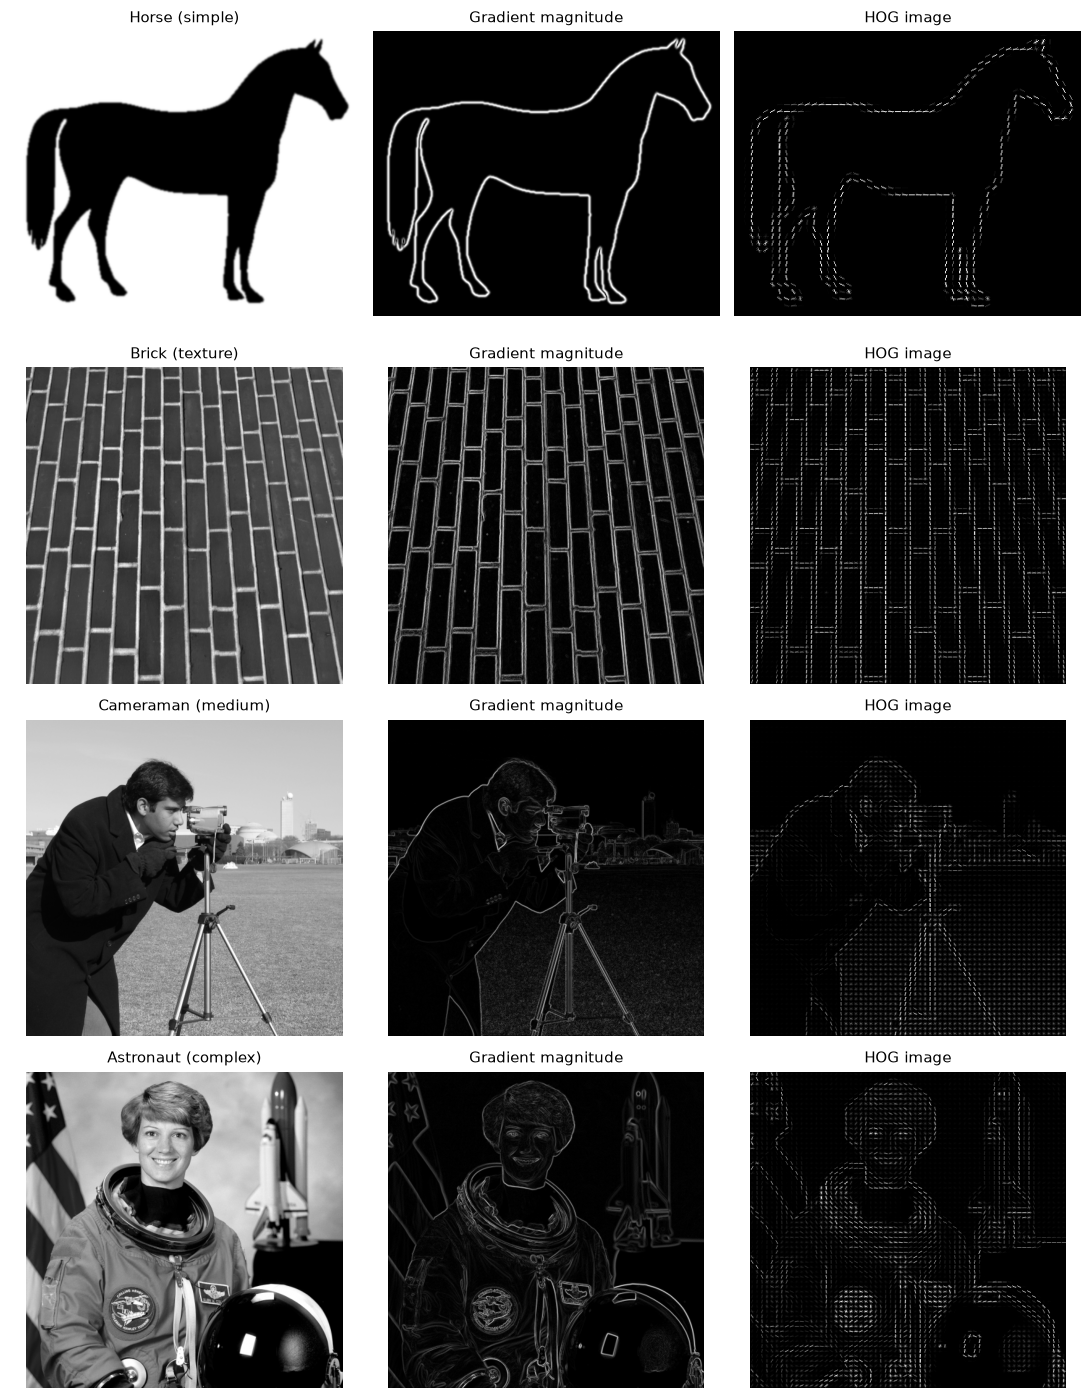

In [43]:
def gradients(img):
    # Centred [-1, 0, 1] derivative - the same one skimage.feature.hog uses.
    gy = np.zeros_like(img); gx = np.zeros_like(img)
    gy[1:-1, :] = img[2:, :] - img[:-2, :]
    gx[:, 1:-1] = img[:, 2:] - img[:, :-2]
    mag = np.hypot(gx, gy)
    ang = np.rad2deg(np.arctan2(gy, gx)) % 180           # unsigned: 0-180 degrees
    return mag, ang

def show_hog(hog_img):
    return exposure.rescale_intensity(hog_img, in_range=(0, hog_img.max() / 2))

fig, ax = plt.subplots(len(results), 3, figsize=(10, 3.2 * len(results)))
for i, (name, r) in enumerate(results.items()):
    mag, ang = gradients(r["img"]); r.update(mag=mag, ang=ang)
    panels = [(r["img"], name, "gray"), (mag, "Gradient magnitude", "gray"),
                (show_hog(r["hog"]), "HOG image", "gray")]
    for j, (im, title, cmap) in enumerate(panels):
        ax[i, j].imshow(im, cmap=cmap); ax[i, j].set_title(title); ax[i, j].axis("off")
plt.tight_layout(); plt.show()

## 4. Comparing HOG features and the effect of the parameters (sub-task 4)

### 4.1 Comparing the four images

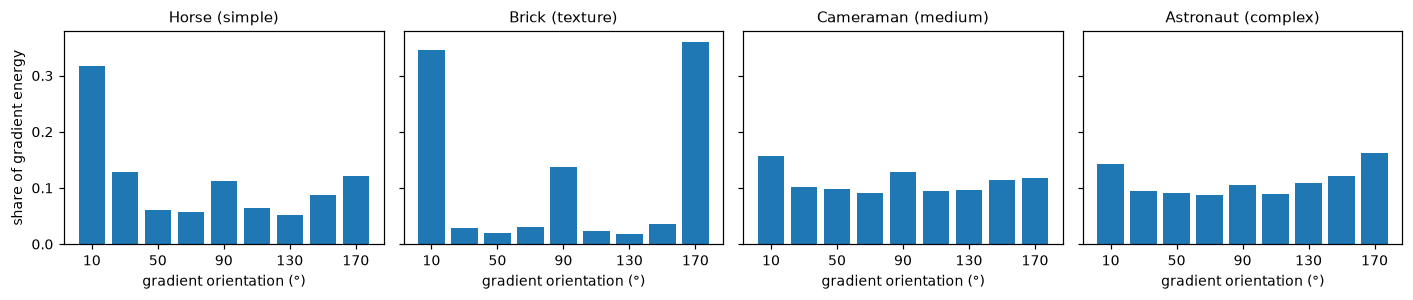

Image                 empty cells  entropy
Horse (simple)                83%     0.91
Brick (texture)               43%     0.72
Cameraman (medium)            44%     0.99
Astronaut (complex)           38%     0.99


In [44]:
def cell_energy_and_hist(img, ppc=8, bins=9):
    # Raw (un-normalised) cell histograms, using hard binning as in skimage.
    mag, ang = gradients(img)
    h, w = img.shape[0] // ppc, img.shape[1] // ppc
    mag, ang = mag[:h*ppc, :w*ppc], ang[:h*ppc, :w*ppc]
    b = np.minimum((ang // (180 / bins)).astype(int), bins - 1)
    cell_id = (np.arange(h*ppc)[:, None] // ppc) * w + (np.arange(w*ppc)[None, :] // ppc)
    hist = np.zeros((h * w, bins))
    np.add.at(hist, (cell_id.ravel(), b.ravel()), mag.ravel())
    return hist.reshape(h, w, bins)

centres = np.arange(10, 180, 20)
rows = []
fig, ax = plt.subplots(1, len(results), figsize=(13, 2.8), sharey=True)
for k, (name, r) in enumerate(results.items()):
    ch = cell_energy_and_hist(r["img"])
    energy = ch.sum(axis=2)
    p = ch.sum(axis=(0, 1)); p = p / p.sum()
    entropy = -(p[p > 0] * np.log(p[p > 0])).sum() / np.log(len(p))
    empty = (energy < 0.05 * energy.max()).mean()
    r.update(p=p, entropy=entropy, empty=empty)
    rows.append((name, empty, entropy))
    ax[k].bar(centres, p, width=16)
    ax[k].set_xticks([10, 50, 90, 130, 170]); ax[k].set_title(name); ax[k].set_xlabel("gradient orientation (°)")
ax[0].set_ylabel("share of gradient energy")
plt.tight_layout(); plt.show()

print(f"{'Image':<21}{'empty cells':>12}{'entropy':>9}")
for n, e, H in rows:
    print(f"{n:<21}{e:>12.0%}{H:>9.2f}")

### 4.2 Cell size

image                  cell   length  shift 4px
Horse (simple)          4px   288684      0.567
Horse (simple)          8px    70560      0.724
Horse (simple)         16px    16416      0.879
Horse (simple)         32px     3564      0.954
Astronaut (complex)     4px   580644      0.658
Astronaut (complex)     8px   142884      0.871
Astronaut (complex)    16px    34596      0.948
Astronaut (complex)    32px     8100      0.984


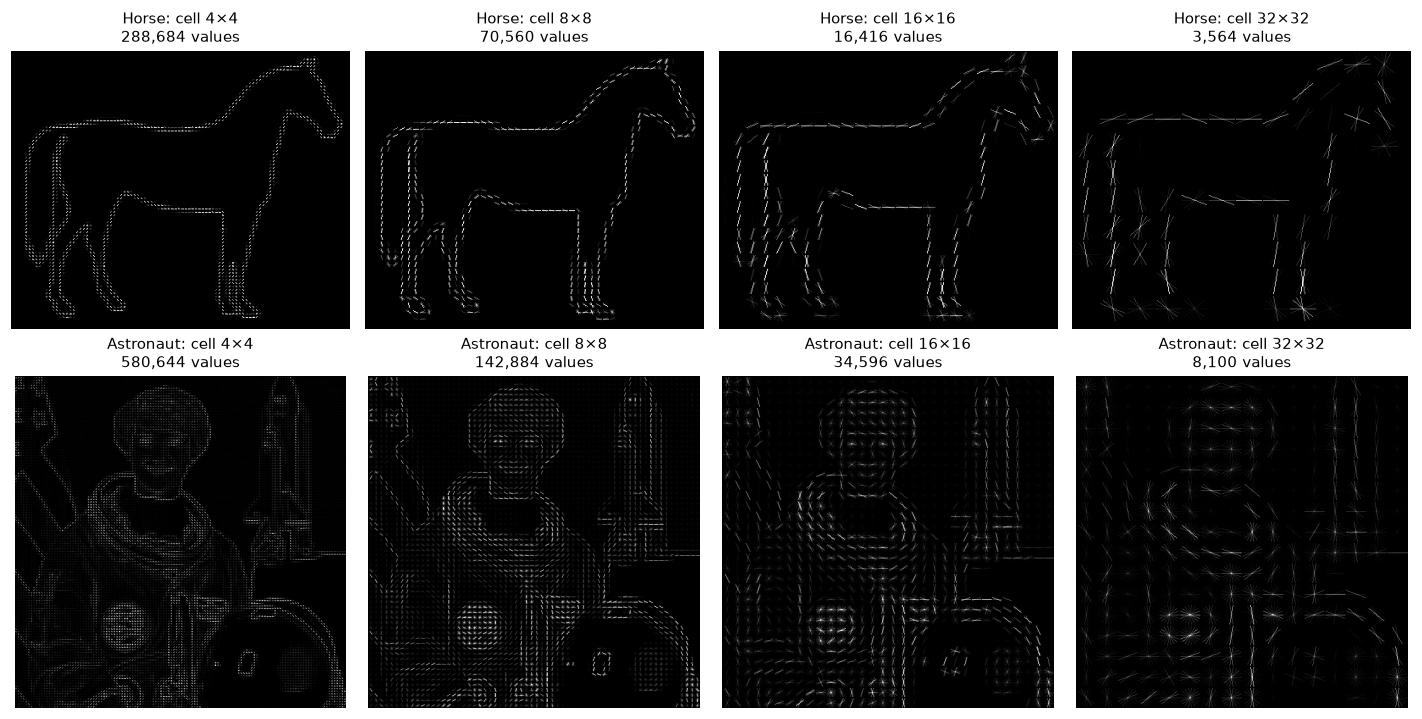

In [45]:
cos = lambda a, b: float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))
cell_sizes = [4, 8, 16, 32]
pair = ["Horse (simple)", "Astronaut (complex)"]

fig, ax = plt.subplots(2, len(cell_sizes), figsize=(13, 6.6))
print(f"{'image':<21}{'cell':>6}{'length':>9}{'shift 4px':>11}")
for i, name in enumerate(pair):
    img = results[name]["img"]; shifted = np.roll(img, 4, axis=1)
    for j, c in enumerate(cell_sizes):
        fd, h = compute_hog(img, pixels_per_cell=(c, c))
        s = cos(fd, compute_hog(shifted, pixels_per_cell=(c, c), visualize=False))
        print(f"{name:<21}{c:>4}px{fd.size:>9}{s:>11.3f}")
        ax[i, j].imshow(show_hog(h), cmap="gray"); ax[i, j].axis("off")
        ax[i, j].set_title(f"{name.split()[0]}: cell {c}×{c}\n{fd.size:,} values")
plt.tight_layout(); plt.show()

### 4.3 Number of orientation bins

image                  bins  bin width   length  rotate 10°
Horse (simple)            2        90°    15680       0.304
Horse (simple)            4        45°    31360       0.268
Horse (simple)            9        20°    70560       0.217
Horse (simple)           18        10°   141120       0.160
Astronaut (complex)       2        90°    31752       0.816
Astronaut (complex)       4        45°    63504       0.685
Astronaut (complex)       9        20°   142884       0.556
Astronaut (complex)      18        10°   285768       0.459


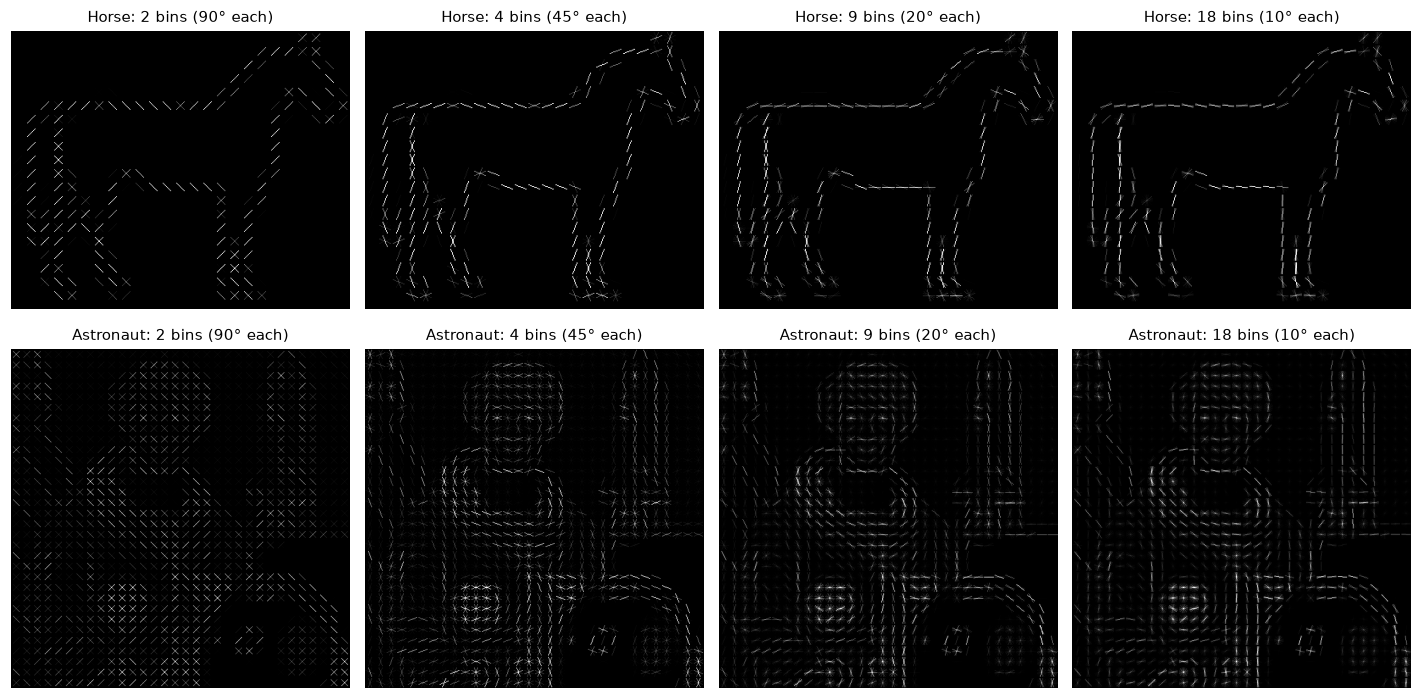

In [46]:
bin_counts = [2, 4, 9, 18]
fig, ax = plt.subplots(2, len(bin_counts), figsize=(13, 6.6))
print(f"{'image':<21}{'bins':>6}{'bin width':>11}{'length':>9}{'rotate 10°':>12}")
for i, name in enumerate(pair):
    img = results[name]["img"]; rotated = transform.rotate(img, 10, mode="edge")
    for j, nb in enumerate(bin_counts):
        # 16x16 cells for the pictures only, so the individual lines in each star are visible
        _, h = compute_hog(img, orientations=nb, pixels_per_cell=(16, 16))
        fd = compute_hog(img, orientations=nb, visualize=False)
        s = cos(fd, compute_hog(rotated, orientations=nb, visualize=False))
        print(f"{name:<21}{nb:>6}{180/nb:>10.0f}°{fd.size:>9}{s:>12.3f}")
        ax[i, j].imshow(show_hog(h), cmap="gray"); ax[i, j].axis("off")
        ax[i, j].set_title(f"{name.split()[0]}: {nb} bins ({180/nb:.0f}° each)")
plt.tight_layout(); plt.show()

### 4.4 Block size and normalisation

In [47]:
img = results["Cameraman (medium)"]["img"]
shadow = img.copy(); shadow[:, img.shape[1] // 2:] *= 0.3     # right half 70 % darker

raw = lambda im: cell_energy_and_hist(im).ravel()              # no normalisation at all
print(f"No normalisation: similarity = {cos(raw(img), raw(shadow)):.3f}")
for b in [1, 2, 3, 4]:
    a = compute_hog(img, cells_per_block=(b, b), visualize=False)
    s = compute_hog(shadow, cells_per_block=(b, b), visualize=False)
    print(f"{b}×{b} cells: length {a.size:>7}, similarity = {cos(a, s):.3f}")

No normalisation: similarity = 0.829
1×1 cells: length   36864, similarity = 0.994
2×2 cells: length  142884, similarity = 0.991
3×3 cells: length  311364, similarity = 0.987
4×4 cells: length  535824, similarity = 0.984


### 4.5 A matching test for all three parameters

87 patch pairs from 5 images

cell size (px)
      4: accuracy 79.3%  (length 8100)
      8: accuracy 74.7%  (length 1764)
     16: accuracy 78.2%  (length 324)
     32: accuracy 27.6%  (length 36)
orientation bins
      2: accuracy 33.3%  (length 392)
      4: accuracy 58.6%  (length 784)
      6: accuracy 67.8%  (length 1176)
      9: accuracy 74.7%  (length 1764)
     12: accuracy 80.5%  (length 2352)
     18: accuracy 85.1%  (length 3528)
cells per block
    1×1: accuracy 44.8%  (length 576)
    2×2: accuracy 74.7%  (length 1764)
    3×3: accuracy 85.1%  (length 2916)
    4×4: accuracy 85.1%  (length 3600)


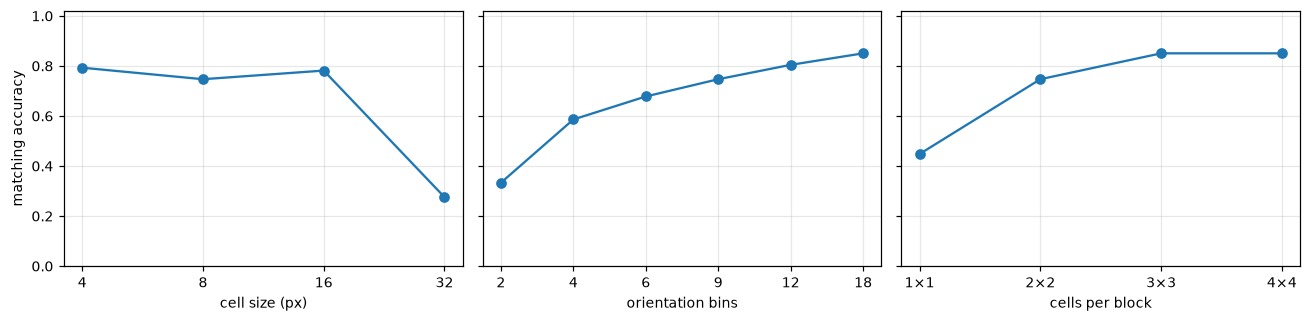

In [48]:
P = 64
sources = [to_grayscale(im, 256) for im in
           [data.camera(), data.astronaut(), data.coffee(), data.chelsea(), data.rocket()]]
rng = np.random.default_rng(0)
gallery, queries = [], []
for im in sources:
    for r in range(8, im.shape[0] - P - 8 + 1, 40):
        for c in range(8, im.shape[1] - P - 8 + 1, 40):
            p = im[r:r+P, c:c+P]
            if p.std() < 0.04:                     # skip flat patches (sky, walls): nothing to describe
                continue
            dy, dx = rng.integers(-2, 3, 2)
            q = transform.rotate(im[r+dy:r+dy+P, c+dx:c+dx+P], rng.uniform(-5, 5), mode="reflect")
            q = np.clip(rng.uniform(.6, 1.2) * q + rng.uniform(-.1, .1) + rng.normal(0, .02, q.shape), 0, 1)
            gallery.append(p); queries.append(q)
print(f"{len(gallery)} patch pairs from {len(sources)} images\n")

def match_accuracy(**kw):
    G = np.array([compute_hog(p, visualize=False, **kw) for p in gallery])
    Q = np.array([compute_hog(q, visualize=False, **kw) for q in queries])
    G /= np.linalg.norm(G, axis=1, keepdims=True) + 1e-12; Q /= np.linalg.norm(Q, axis=1, keepdims=True) + 1e-12
    return ((Q @ G.T).argmax(axis=1) == np.arange(len(G))).mean(), G.shape[1]

experiments = {
    "cell size (px)":    [(f"{c}", {"pixels_per_cell": (c, c), "cells_per_block": (1, 1) if c == 32 else (2, 2)}) for c in [4, 8, 16, 32]],
    "orientation bins":  [(f"{b}", {"orientations": b}) for b in [2, 4, 6, 9, 12, 18]],
    "cells per block":   [(f"{b}×{b}", {"cells_per_block": (b, b)}) for b in [1, 2, 3, 4]],
}
fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for a_, (param, settings) in zip(ax, experiments.items()):
    accs = []
    print(param)
    for label, kw in settings:
        acc, L = match_accuracy(**kw); accs.append(acc)
        print(f"  {label:>5}: accuracy {acc:5.1%}  (length {L})")
    a_.plot([l for l, _ in settings], accs, "o-"); a_.set_xlabel(param); a_.set_ylim(0, 1.02); a_.grid(alpha=.3)
ax[0].set_ylabel("matching accuracy")
plt.tight_layout(); plt.show()